In [6]:
# Reqired libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import seaborn as sns
from itertools import product
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

### Helper functions to create a Boolean network (from practical)


In [7]:
# 🟢 Helper class to build and simulate boolean network

class BooleanNetwork:
    def __init__(self, node_names):
        self.nodes = {name: 0 for name in node_names}
        self.rules = {}
        self.history = []
        self.graph = nx.DiGraph()  # NetworkX graph for visualization

        # Add nodes to NetworkX graph
        self.graph.add_nodes_from(node_names)

    def add_rule(self, target_node, rule_function, rule_description=""):
        """
        Add Boolean rule for a node

        Args:
            target_node: Node to update
            rule_function: Function that takes current state dict and returns True/False
            rule_description: Human-readable description
        """
        self.rules[target_node] = {
            'function': rule_function,
            'description': rule_description
        }

    def set_state(self, **kwargs):
        """Set states of specific nodes"""
        for node, value in kwargs.items():
            if node in self.nodes:
                self.nodes[node] = int(bool(value))

    def get_state_vector(self):
        """Get current state as list in sorted order"""
        return [self.nodes[node] for node in sorted(self.nodes.keys())]

    def update_synchronous(self):
        """Update all nodes simultaneously"""
        new_state = {}
        for node in self.nodes:
            if node in self.rules:
                new_state[node] = int(self.rules[node]['function'](self.nodes))
            else:
                new_state[node] = self.nodes[node]  # No rule = no change

        self.nodes = new_state
        self.history.append(self.get_state_vector())

    def simulate(self, steps=10, record_history=True):
        """Run simulation"""
        if record_history:
            self.history = [self.get_state_vector()]

        for step in range(steps):
            self.update_synchronous()

            # Check for steady state
            if len(self.history) >= 2 and self.history[-1] == self.history[-2]:
                print(f"   Reached steady state after {step+1} steps")
                break

        return np.array(self.history)



---





---



## Part 1. Create regulatory network with mutations

🧬 Biological context

Cells make binary decisions:
* GROW: Divide and multiply (good for healing, bad if uncontrolled)
* DIE: Self-destruct (protective mechanism, prevents cancer)
* REST: Stay inactive (safe default state)

Key molecular switches (think: binary variables):
* DNA_damage: External damage signal (input variable)
* p53: "Tumor suppressor" - master safety switch that detects problems
* MYC: "Oncogene" - growth promoter that drives cell division
* CDK2: Cell division machinery that executes growth
* MDM2: "p53 inhibitor" - blocks p53 function (cancer exploit!)
* p21: "Cell cycle brake" - stops division when problems detected
* Growth/Death: Final binary decisions (outputs)

## Description of molecules

In [8]:
# 🟢 Create the regulatory network
nodes = ['DNA_damage', 'p53', 'MYC', 'CDK2', 'MDM2', 'p21', 'Growth', 'Death']
node_names=sorted(nodes)

# a function for building a Boolean network wit mutation parameter
def create_network(mutation=None):
    """
    Builds a Boolean network.

    mutation:
        None = normal network
        'A'  = p53 knockout
        'B'  = MYC amplification
        'C'  = MDM2 overexpression
        'D'  = p21 knockout
    """

    network = BooleanNetwork(nodes)

    # add normal boolean rules from practical
    network.add_rule('DNA_damage', lambda s: s['DNA_damage'], "DNA_damage = INPUT (constant)")
    network.add_rule('p21', lambda s: s['p53'], "p21 = p53")
    network.add_rule('MYC', lambda s: (not s['p53']) and (not s['p21']), "MYC = (NOT p53) AND (NOT p21)")
    network.add_rule('CDK2', lambda s: s['MYC'] and (not s['p21']) and (not s['p53']), "CDK2 = MYC AND (NOT p21) AND (NOT p53)")
    network.add_rule('MDM2', lambda s: s['MYC'], "MDM2 = MYC")
    network.add_rule('p53', lambda s: s['DNA_damage'] and not s['MDM2'], "p53 = DNA_damage AND (NOT MDM2)")
    network.add_rule('Growth',lambda s: s['CDK2'] and s['MYC'] and (not s['p53']), "Growth = CDK2 AND MYC AND (NOT p53)")
    network.add_rule('Death', lambda s: s['p53'] and s['DNA_damage'] and (not s['Growth']), "Death = p53 AND DNA_damage AND (NOT Growth)")
    

    # added rules for mutation

    # Mutation A: p53 Knockout
    if mutation == 'A':
        network.add_rule('p53',lambda s: False,"p53 = BROKEN (always OFF)")

    # Mutation B: MYC Amplification
    elif mutation == 'B':
        network.add_rule('MYC', lambda s: True, "MYC = AMPLIFIED (always ON)")

    # Mutation C: MDM2 Overexpression
    elif mutation == 'C':
        network.add_rule('MDM2', lambda s: True, "MDM2 = OVEREXPRESSED (always ON)")

    # Mutation D: p21 Knockout - we simulate a loss of an important cell-cycle inhibitor
    elif mutation == 'D':
        network.add_rule('p21',lambda s: False,"p21 = KNOCKOUT (always OFF)" )

    return network


# All versions of the network
network_variants = {
    'Normal Network': None,
    'Mutation A - p53 Knockout': 'A',
    'Mutation B - MYC Amplification': 'B',
    'Mutation C - MDM2 Overexpression': 'C',
    'Mutation D - p21 Knockout': 'D'
}


# show rules fro each network

for network_name, mutation in network_variants.items():

    network = create_network(mutation)

    print("\n" + "=" * 70)
    print(network_name)
    print("=" * 70)

    for node, rule_info in network.rules.items():
        print(f"{node:12s}: {rule_info['description']}")


Normal Network
DNA_damage  : DNA_damage = INPUT (constant)
p21         : p21 = p53
MYC         : MYC = (NOT p53) AND (NOT p21)
CDK2        : CDK2 = MYC AND (NOT p21) AND (NOT p53)
MDM2        : MDM2 = MYC
p53         : p53 = DNA_damage AND (NOT MDM2)
Growth      : Growth = CDK2 AND MYC AND (NOT p53)
Death       : Death = p53 AND DNA_damage AND (NOT Growth)

Mutation A - p53 Knockout
DNA_damage  : DNA_damage = INPUT (constant)
p21         : p21 = p53
MYC         : MYC = (NOT p53) AND (NOT p21)
CDK2        : CDK2 = MYC AND (NOT p21) AND (NOT p53)
MDM2        : MDM2 = MYC
p53         : p53 = BROKEN (always OFF)
Growth      : Growth = CDK2 AND MYC AND (NOT p53)
Death       : Death = p53 AND DNA_damage AND (NOT Growth)

Mutation B - MYC Amplification
DNA_damage  : DNA_damage = INPUT (constant)
p21         : p21 = p53
MYC         : MYC = AMPLIFIED (always ON)
CDK2        : CDK2 = MYC AND (NOT p21) AND (NOT p53)
MDM2        : MDM2 = MYC
p53         : p53 = DNA_damage AND (NOT MDM2)
Growth   

In [9]:
# Three required scenarios

scenarios = {
    'Healthy Cell': {'DNA_damage': 0, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Stressed Cell': { 'DNA_damage': 1, 'p53': 0, 'MYC': 0, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0},
    'Oncogene Hijacked Cell': { 'DNA_damage': 0, 'p53': 0, 'MYC': 1, 'CDK2': 0, 'MDM2': 0, 'p21': 0, 'Growth': 0, 'Death': 0}
}

scenario_results = {}
scenario_summary =[]


for network_name, mutation in network_variants.items():

    print("\n")
    print("=" * 80)
    print(network_name)
    print("=" * 80)

    scenario_results[network_name] = {}


    for scenario_name, initial_state in scenarios.items(): # here we have to make sure, that the overexpressed genes are overexpressed also at t=0

        print(f"\nScenario: {scenario_name}")

        network = create_network(mutation)

        # We make a copy so the original scenario is not changed
        mutated_initial_state = initial_state.copy()

        # the mutation has to be present from time step 0
        if mutation == 'A':
            mutated_initial_state['p53'] = 0

        elif mutation == 'B':
            mutated_initial_state['MYC'] = 1

        elif mutation == 'C':
            mutated_initial_state['MDM2'] = 1

        elif mutation == 'D':
            mutated_initial_state['p21'] = 0

        network.set_state(**mutated_initial_state)

        trajectory = network.simulate(steps=8)

    

        # Save result
        scenario_results[network_name][scenario_name] = trajectory

        # Final state
        final_state = trajectory[-1]
        final_dict = {node:int(final_state[i]) for i, node in enumerate(node_names)}

        print(
            f"   Final state: "
            f"Growth={final_dict['Growth']}, "
            f"Death={final_dict['Death']}, "
            f"p53={final_dict['p53']}, "
            f"MYC={final_dict['MYC']}, "
            f"p21={final_dict['p21']}, "
            f"DNA_damage={final_dict['DNA_damage']}"
        )


        # Store summary
        scenario_summary.append({'Network': network_name,'Scenario':scenario_name,'DNA Damage':final_dict['DNA_damage'],'p53':final_dict['p53'],'p21':final_dict['p21'],'MYC':final_dict['MYC'],'CDK2':final_dict['CDK2'],'MDM2':final_dict['MDM2'],'Growth': final_dict['Growth'],'Death':final_dict['Death']})


# scenario summary table
scenario_df = pd.DataFrame(scenario_summary)

print("\n")
print("=" * 80)
print("SCENARIO SUMMARY TABLE")
print("=" * 80)

print(scenario_df.to_string(index=False))





Normal Network

Scenario: Healthy Cell
   Reached steady state after 4 steps
   Final state: Growth=1, Death=0, p53=0, MYC=1, p21=0, DNA_damage=0

Scenario: Stressed Cell
   Reached steady state after 6 steps
   Final state: Growth=0, Death=1, p53=1, MYC=0, p21=1, DNA_damage=1

Scenario: Oncogene Hijacked Cell
   Reached steady state after 3 steps
   Final state: Growth=1, Death=0, p53=0, MYC=1, p21=0, DNA_damage=0


Mutation A - p53 Knockout

Scenario: Healthy Cell
   Reached steady state after 4 steps
   Final state: Growth=1, Death=0, p53=0, MYC=1, p21=0, DNA_damage=0

Scenario: Stressed Cell
   Reached steady state after 4 steps
   Final state: Growth=1, Death=0, p53=0, MYC=1, p21=0, DNA_damage=1

Scenario: Oncogene Hijacked Cell
   Reached steady state after 3 steps
   Final state: Growth=1, Death=0, p53=0, MYC=1, p21=0, DNA_damage=0


Mutation B - MYC Amplification

Scenario: Healthy Cell
   Reached steady state after 3 steps
   Final state: Growth=1, Death=0, p53=0, MYC=1, p21

## Testing scenarios

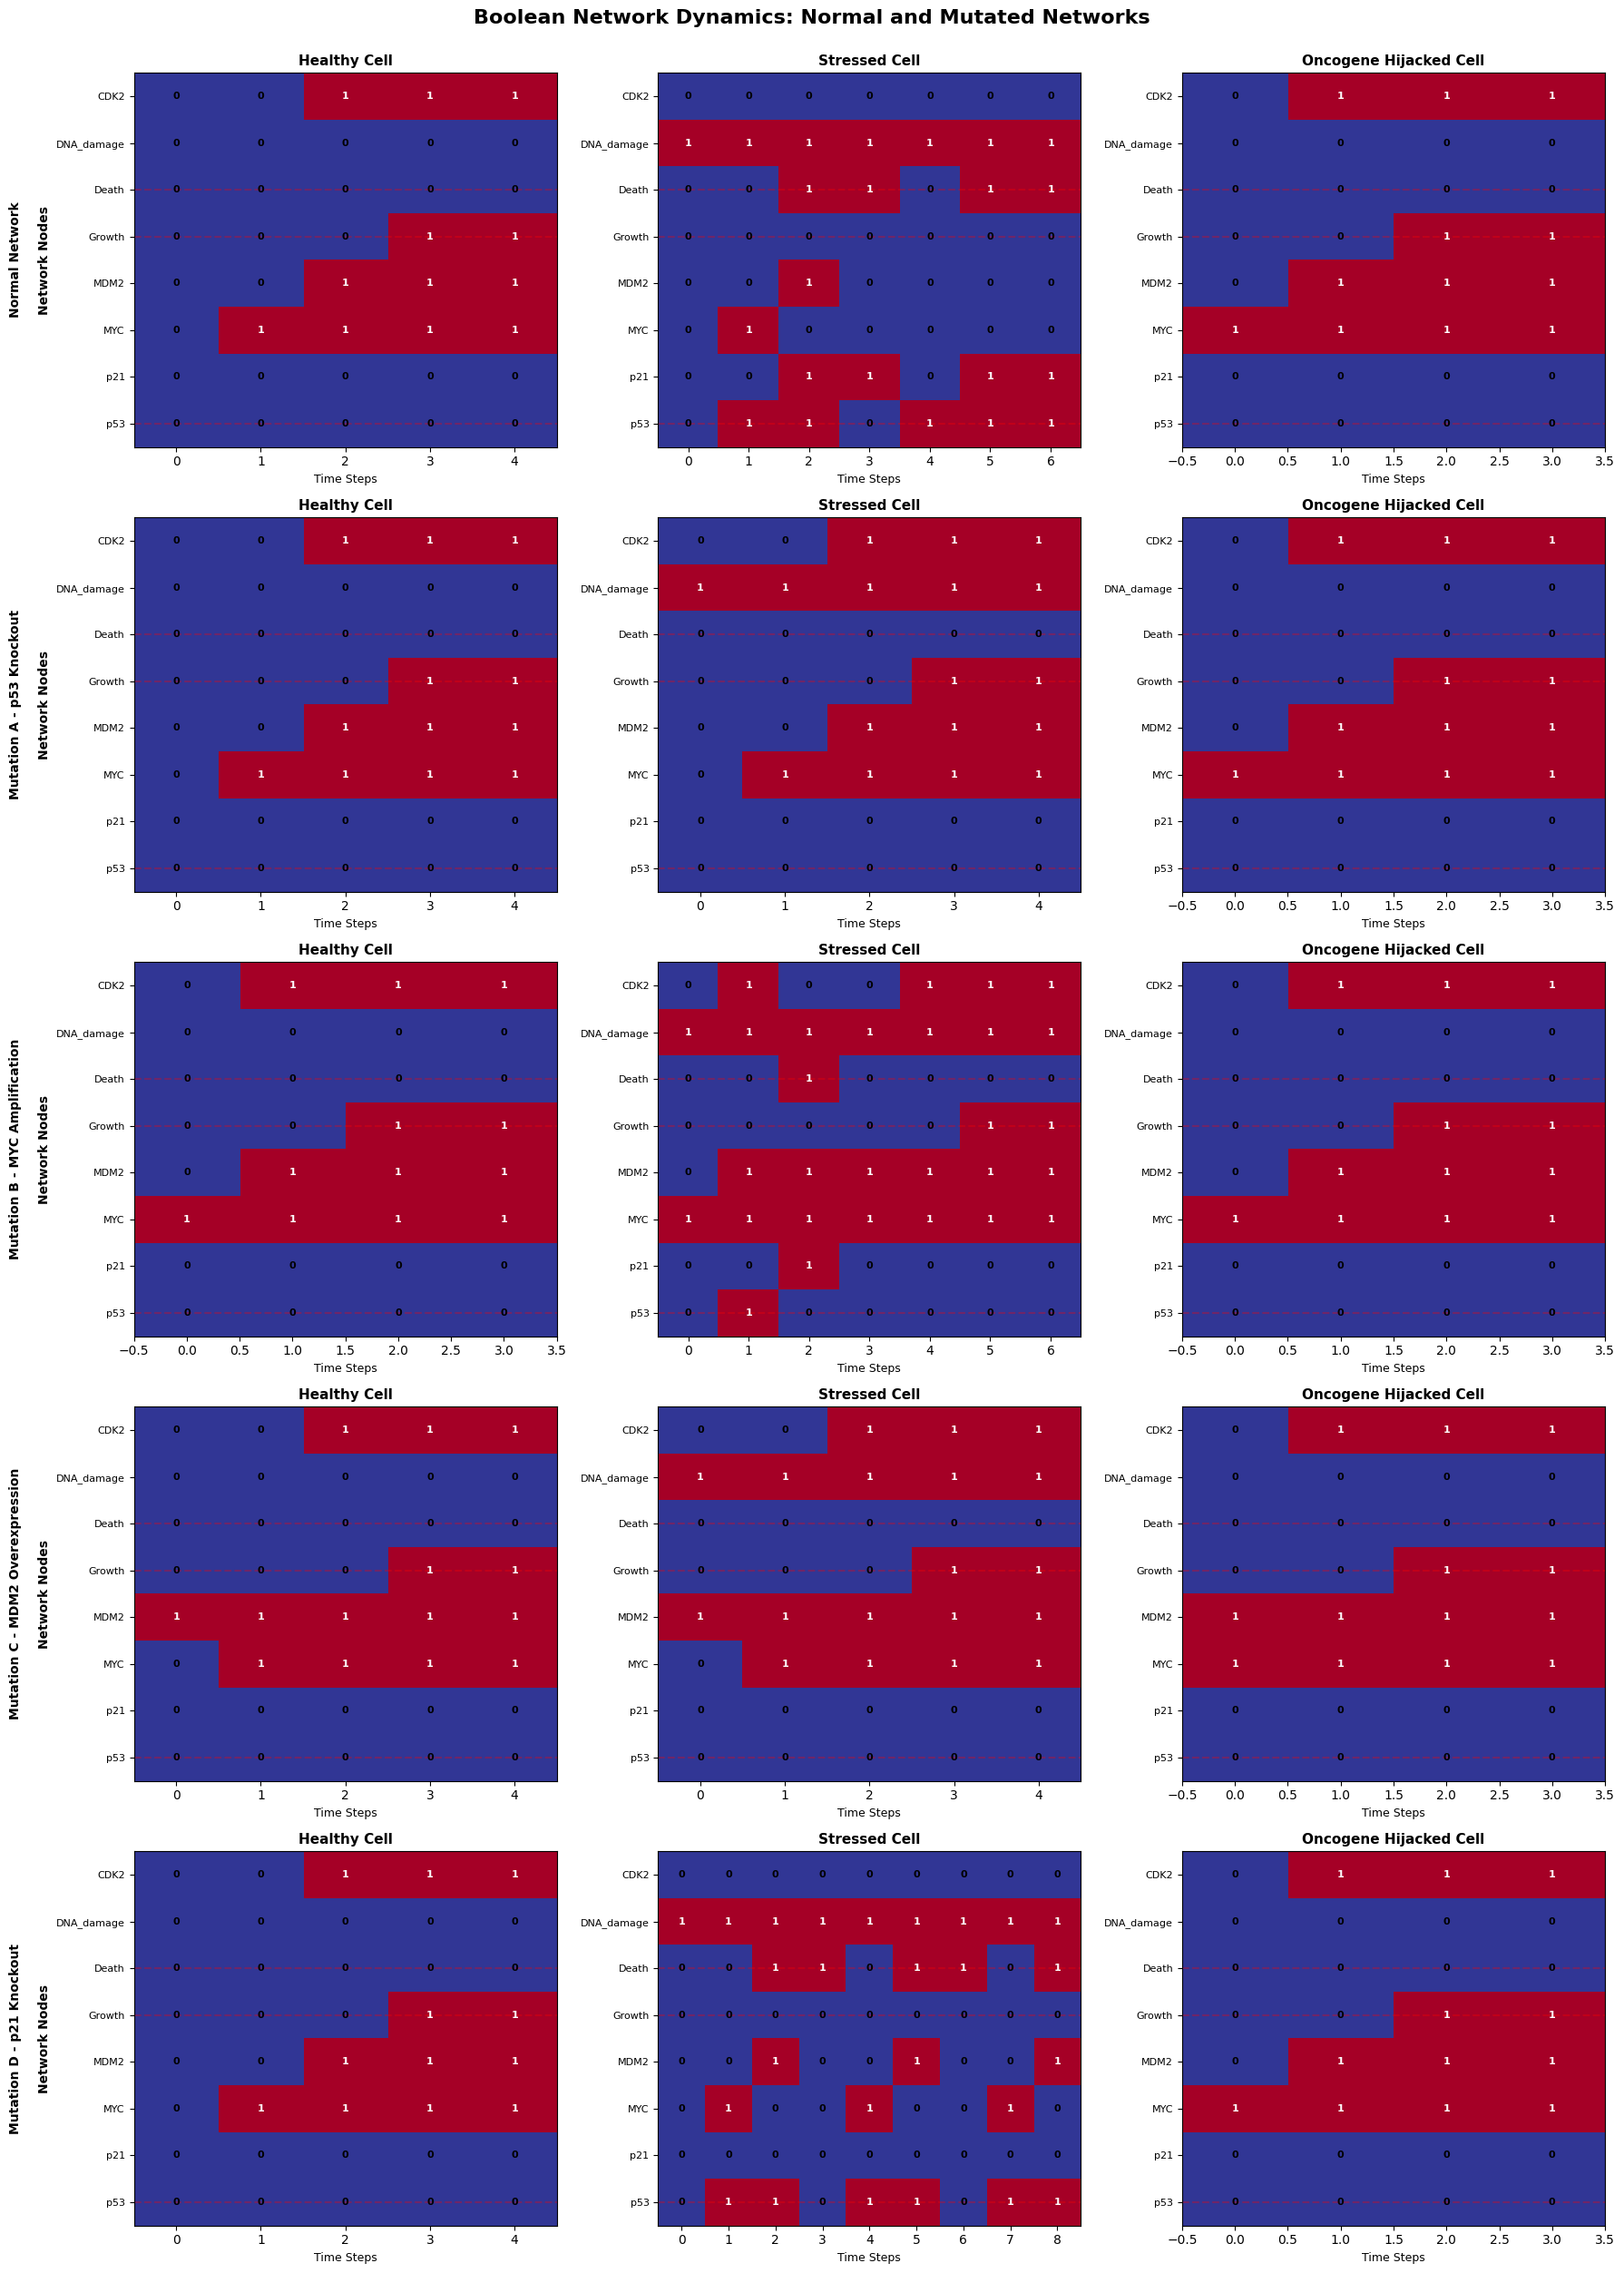

In [5]:
# visualize results for all mutation-scenario combination
fig, axes = plt.subplots(len(network_variants), len(scenarios), figsize=(18, 25))

for row, network_name in enumerate(network_variants.keys()):
    for col, scenario_name in enumerate(scenarios.keys()):
        ax = axes[row, col]
        trajectory = scenario_results[network_name][scenario_name]
        trajectory_matrix = trajectory.T # Transpose: rows = network nodes, columns = time points

        im = ax.imshow(trajectory_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
        ax.set_title(scenario_name, fontsize=11, fontweight='bold')
        ax.set_xlabel('Time Steps', fontsize=9)
        ax.set_yticks(range(len(node_names)))
        ax.set_yticklabels(node_names, fontsize=8)

        if col == 0: ax.set_ylabel(network_name + '\n\nNetwork Nodes', fontsize=10, fontweight='bold')

        # adding 0/1 annotations
        for t in range(trajectory.shape[0]):
            for n in range(len(node_names)):
                value = trajectory_matrix[n, t]
                text_color = 'white' if value == 1 else 'black'
                ax.text(t, n, int(value), ha='center', va='center', color=text_color, fontweight='bold', fontsize=8)

        # highlight important output nodes
        for output_node in ['Growth', 'Death', 'p53']: ax.axhline(y=node_names.index(output_node), color='red', linestyle='--', alpha=0.3, linewidth=1.5)

plt.suptitle('Boolean Network Dynamics: Normal and Mutated Networks', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


---

## **Part 3: Attractor analysis**



In [10]:

# IMPORTANT: here we use the practical network.simulate() function. An attractor is recorded when
# the last two states are identical: trajectory[-1] == trajectory[-2]. Therefore, we in fact check only for steady-state attractors


max_steps = 15
n_nodes = len(node_names)
total_states = 2 ** n_nodes

print("\n")
print("=" * 80)
print("ATTRACTOR ANALYSIS")
print("=" * 80)
print(f"There are {n_nodes} nodes, so {total_states} possible initial states will be tested for each network.")

# store attractors for every network
all_network_attractors = {}

for network_name, mutation in network_variants.items():
    print("\n")
    print("=" * 80)
    print(f"ATTRACTOR ANALYSIS: {network_name}")
    print("=" * 80)

    # create a new network
    network = create_network(mutation)

    # a list of unique attractors
    attractors = []

    print(f"Testing all {2 ** n_nodes} possible initial states...")

    # generate all possible combinations
    all_states = list(product([0, 1], repeat=n_nodes))

    # testing every possible initial state   
    for initial_state in all_states:
        
        state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}

        # setting network state
        network.set_state(**state_dict)

        trajectory = network.simulate(max_steps)
        if len(trajectory) >= 2:
            # steady state when the final two states are identical
            if np.array_equal(trajectory[-1], trajectory[-2]):
                final_state = tuple(int(x) for x in trajectory[-1])

                # Only store new attractors
                if final_state not in attractors:
                    attractors.append(final_state)

    # Save attractors
    all_network_attractors[network_name] = attractors

    # display attractors
    print(f"\nFOUND {len(attractors)} STEADY-STATE ATTRACTORS:")

    for i, attractor in enumerate(attractors):
        print("\n")
        print(f"Attractor {i + 1}: {list(attractor)}")

        # convert attractor into dictionary
        state_dict = {node_names[j]: attractor[j] for j in range(len(node_names))}

        # key outputs
        growth_active = state_dict['Growth'] == 1
        death_active = state_dict['Death'] == 1
        p53_active = state_dict['p53'] == 1
        dna_damage_active = state_dict['DNA_damage'] == 1

        print(f"   Growth: {'ON' if growth_active else 'OFF'}")
        print(f"   Death: {'ON' if death_active else 'OFF'}")
        print(f"   p53: {'ON' if p53_active else 'OFF'}")
        print(f"   DNA Damage: {'ON' if dna_damage_active else 'OFF'}")

        




ATTRACTOR ANALYSIS
There are 8 nodes, so 256 possible initial states will be tested for each network.


ATTRACTOR ANALYSIS: Normal Network
Testing all 256 possible initial states...
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady 



ATTRACTOR HEATMAPS


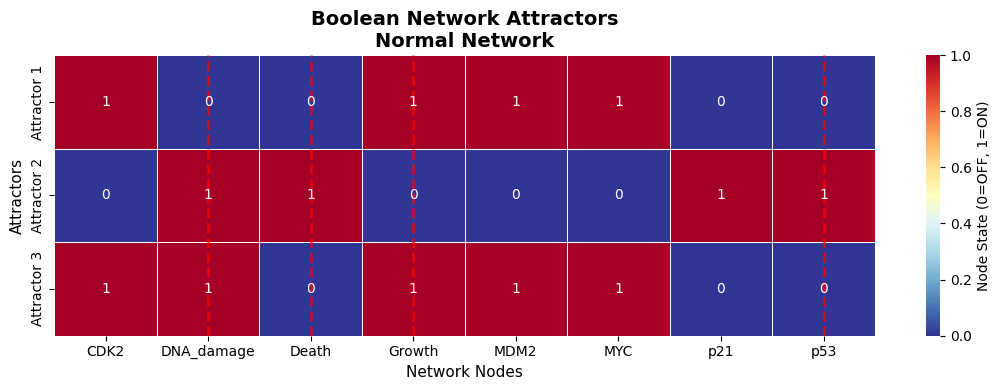

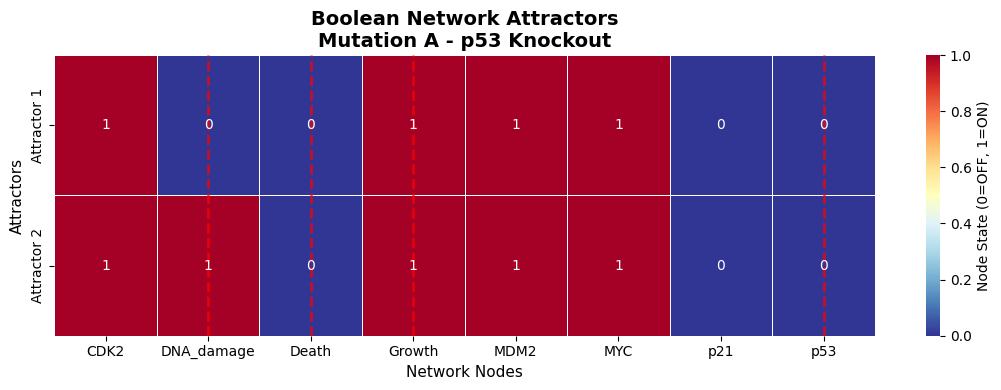

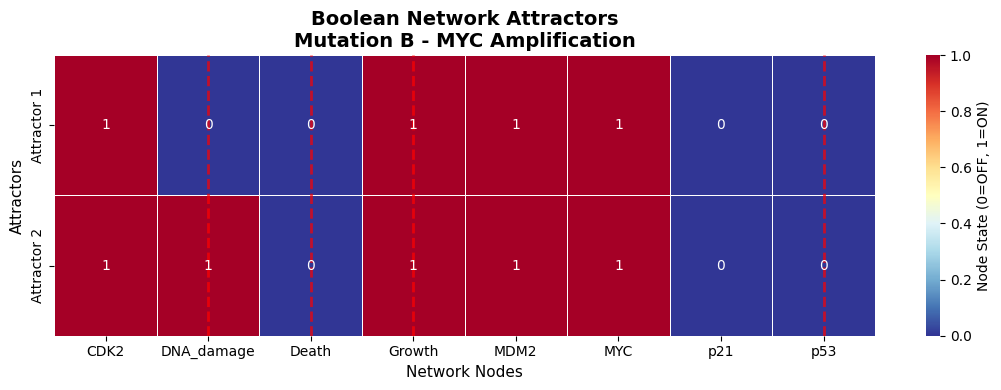

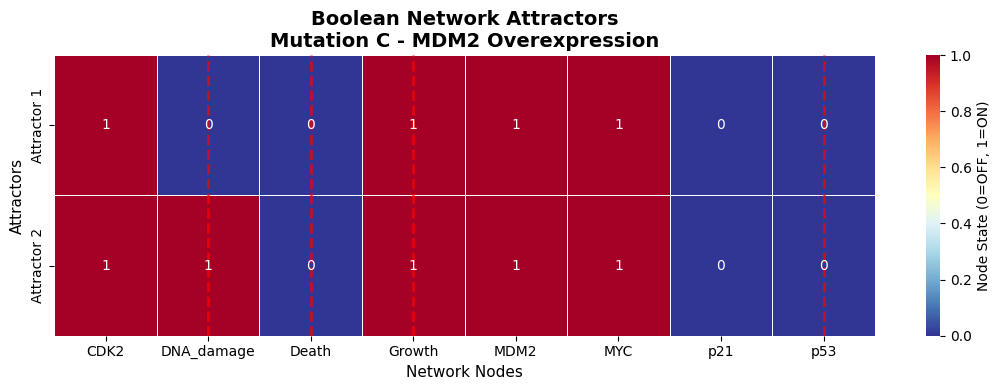

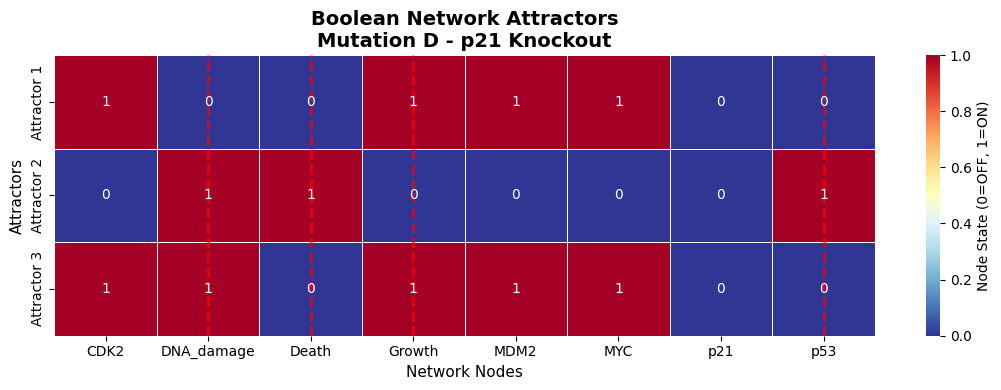

In [7]:
# Attractor heatmap visualization

print("\n")
print("=" * 80)
print("ATTRACTOR HEATMAPS")
print("=" * 80)

for network_name, attractors in all_network_attractors.items():
    # in case no steady-state attractor was found
    if len(attractors) == 0:
        print(f"\n{network_name}: No steady-state attractors were detected within {max_steps} steps.")
        continue

    # Convert attractors into a matrix
    attractor_matrix = []
    for attractor in attractors:
        clean_row = [int(x) for x in attractor]
        attractor_matrix.append(clean_row)

    attractor_matrix = np.array(attractor_matrix)

    # create heatmap
    plt.figure(figsize=(11, max(4, len(attractors))))
    ax = sns.heatmap(attractor_matrix, xticklabels=node_names, yticklabels=[f'Attractor {i + 1}' for i in range(len(attractors))], cmap='RdYlBu_r', vmin=0, vmax=1, cbar_kws={'label': 'Node State (0=OFF, 1=ON)'}, annot=True, fmt='d', linewidths=0.5)

    plt.title(f'Boolean Network Attractors\n{network_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Network Nodes', fontsize=11)
    plt.ylabel('Attractors', fontsize=11)

    # highlight important nodes
    output_nodes = ['Growth', 'Death', 'p53', 'DNA_damage']

    for node in output_nodes:
        idx = node_names.index(node)
        ax.axvline(x=idx + 0.5, color='red', linestyle='--', alpha=0.7, linewidth=2)

    plt.tight_layout()
    plt.show()




## How many initial states reach each attractor? Most popular basins?




BASIN OF ATTRACTION ANALYSIS


BASIN ANALYSIS: Normal Network
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 4 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state after 3 steps
   Reached steady state after 6 steps
   Reached steady state after 5 steps
   Reached steady state after 6 steps
   Reached steady state 

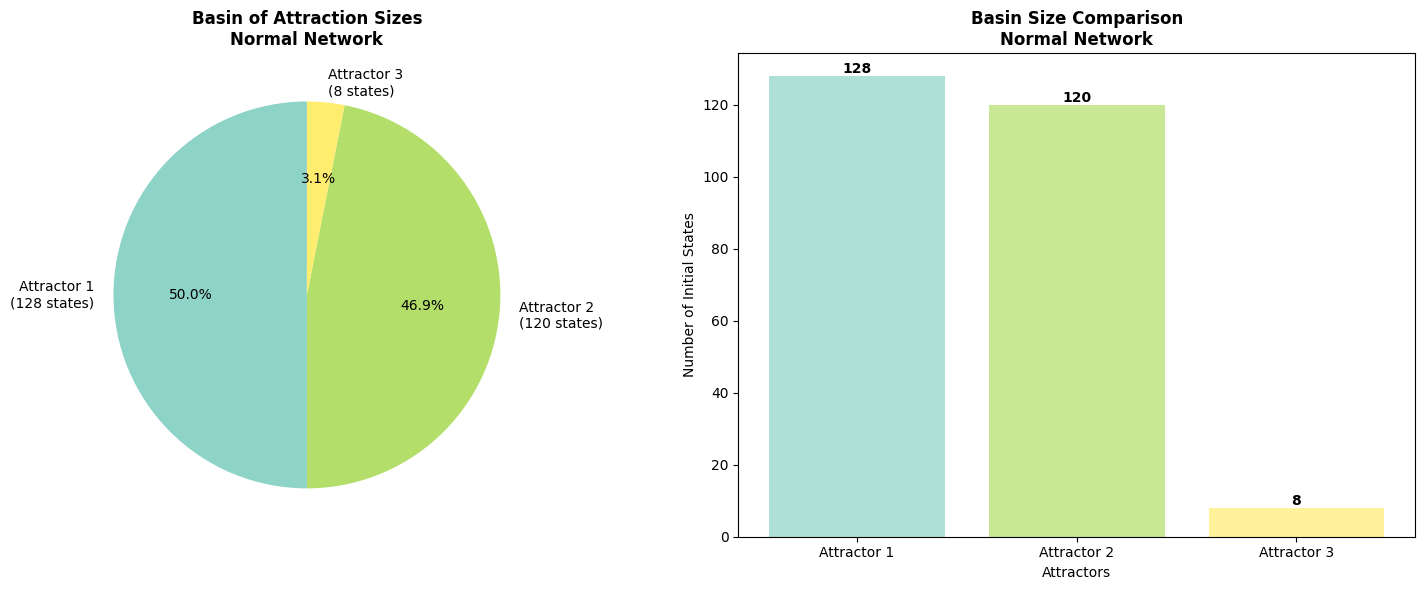

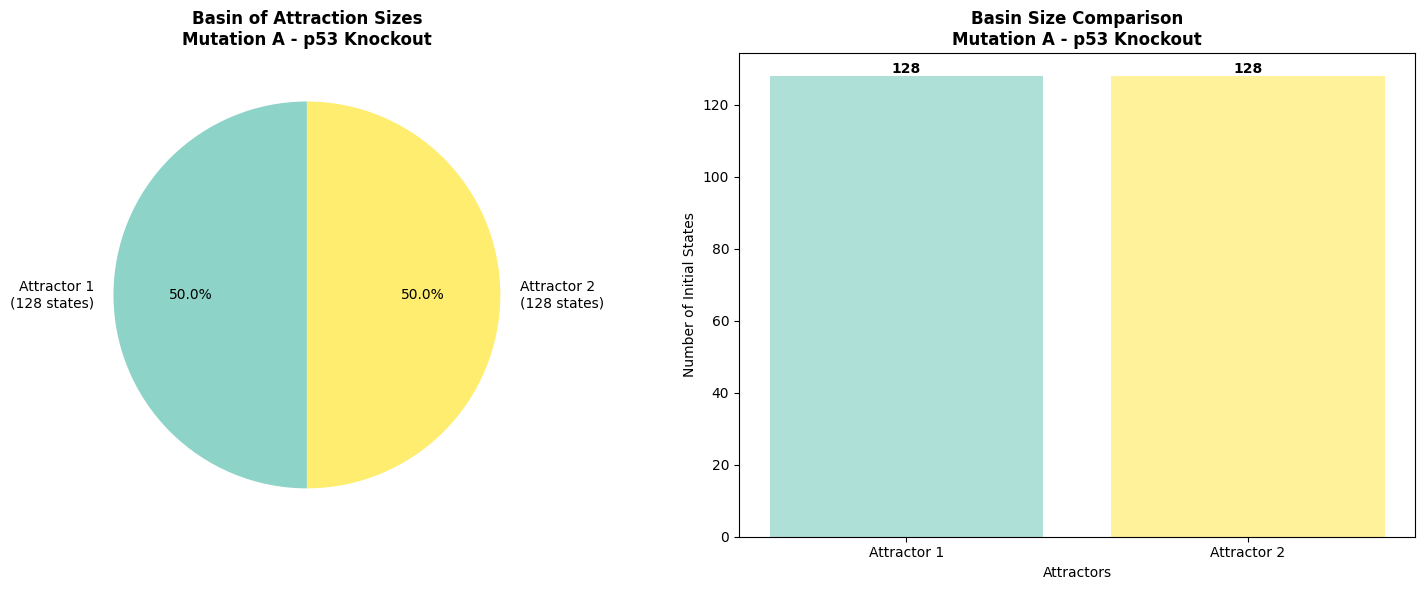

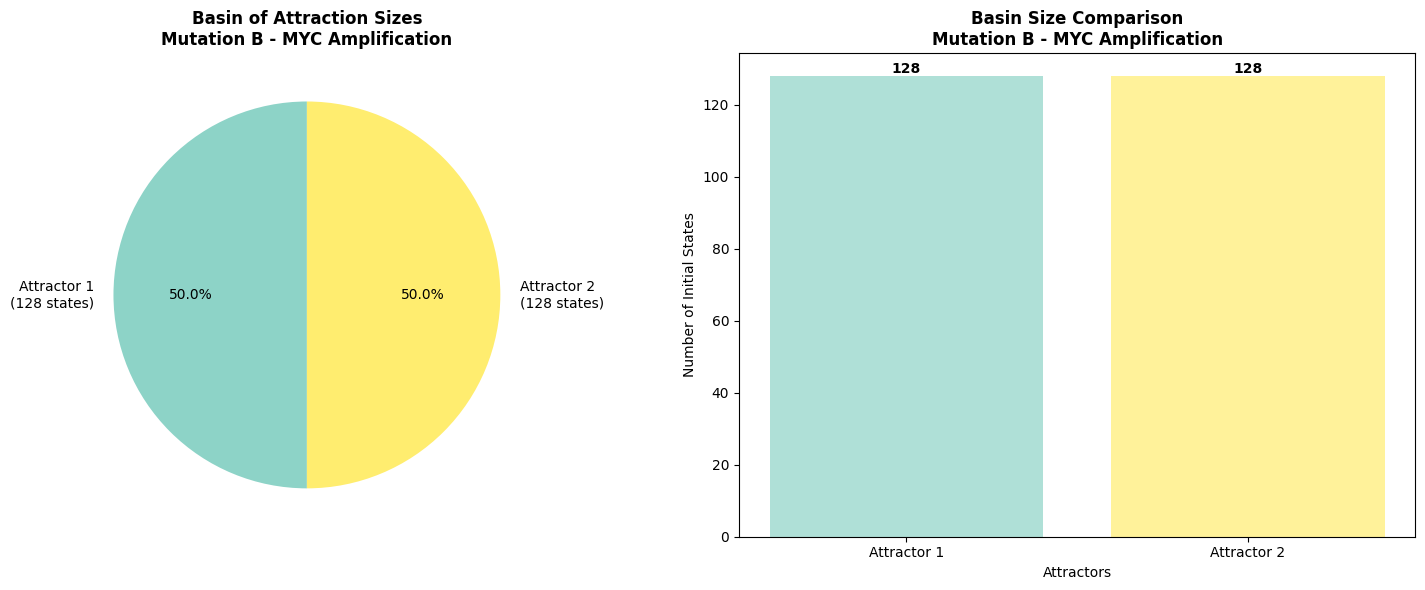

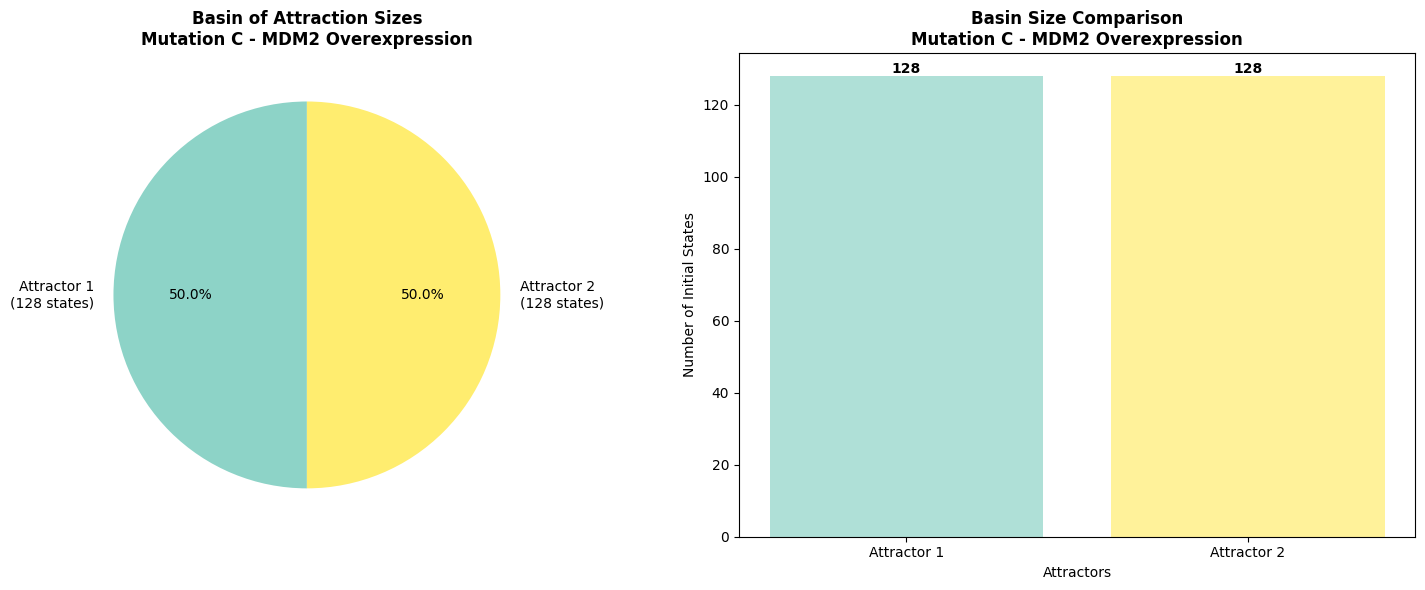

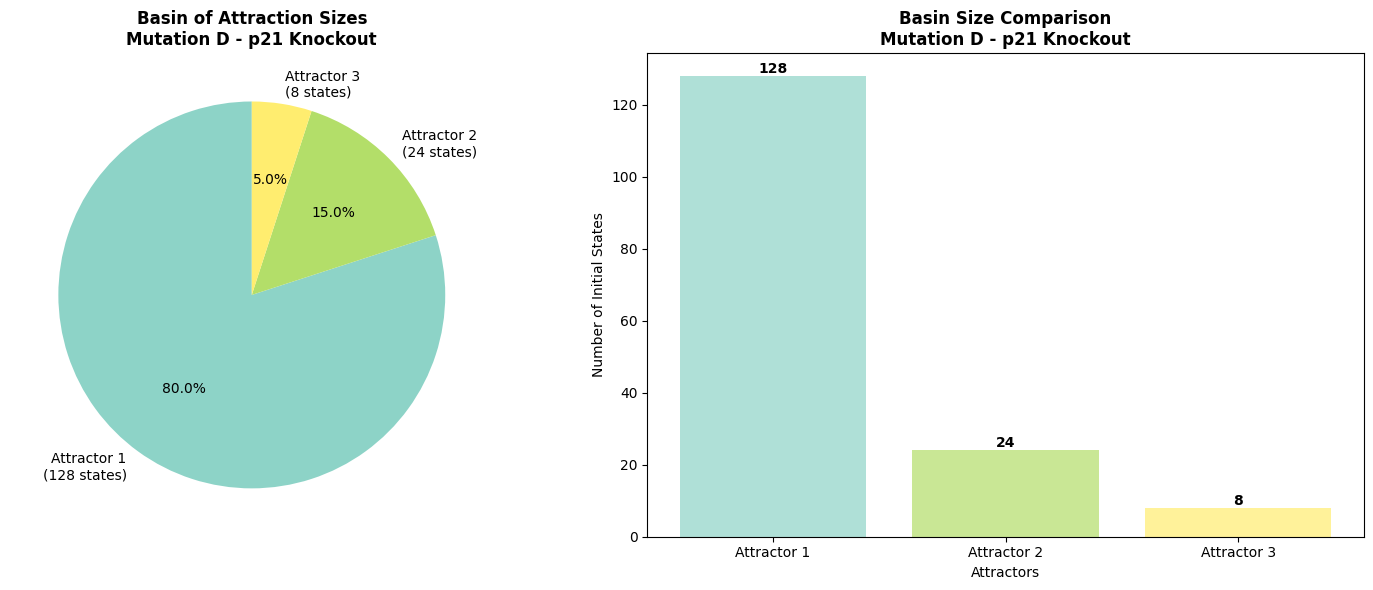

In [8]:

print("\n")
print("=" * 80)
print("BASIN OF ATTRACTION ANALYSIS")
print("=" * 80)

all_basin_data = {}

for network_name, mutation in network_variants.items():
    print("\n")
    print("=" * 80)
    print(f"BASIN ANALYSIS: {network_name}")
    print("=" * 80)

    network = create_network(mutation)
    attractors = all_network_attractors[network_name]

    # attractor index -> list of initial states
    basin_data = defaultdict(list)
    all_states = list(product([0, 1], repeat=n_nodes))

    for initial_state in all_states:
        state_dict = {node_names[i]: initial_state[i] for i in range(n_nodes)}
        network.set_state(**state_dict)
        trajectory = network.simulate(steps=max_steps, record_history=True)

        # Check for steady state
        if len(trajectory) >= 2 and np.array_equal(trajectory[-1], trajectory[-2]):
            final_state = tuple(int(x) for x in trajectory[-1])

            # Match final state to attractor
            for att_idx, attractor in enumerate(attractors):
                clean_attractor = tuple(int(x) for x in attractor)
                if final_state == clean_attractor:
                    basin_data[att_idx].append(initial_state)
                    break

    # save basin data
    all_basin_data[network_name] = basin_data

    print("\nBasin Sizes:")

    for att_idx in range(len(attractors)):
        basin_size = len(basin_data[att_idx])
        percentage = (basin_size / total_states) * 100
        print(f"   Attractor {att_idx + 1}: {basin_size:3d} states ({percentage:5.1f}%)")


# Basin size visualizations

for network_name, attractors in all_network_attractors.items():
    if len(attractors) == 0:
        continue

    basin_data = all_basin_data[network_name]
    basin_sizes = [len(basin_data[i]) for i in range(len(attractors))]
    basin_labels = [f'Attractor {i + 1}\n({size} states)' for i, size in enumerate(basin_sizes)]
    attractor_names = [f'Attractor {i + 1}' for i in range(len(attractors))]
    colors = plt.cm.Set3(np.linspace(0, 1, len(attractors)))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Pie chart
    ax1.pie(basin_sizes, labels=basin_labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax1.set_title(f'Basin of Attraction Sizes\n{network_name}', fontsize=12, fontweight='bold')

    # Bar chart
    bars = ax2.bar(attractor_names, basin_sizes, color=colors, alpha=0.7)
    ax2.set_title(f'Basin Size Comparison\n{network_name}', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Initial States', fontsize=10)
    ax2.set_xlabel('Attractors', fontsize=10)

    # Add values above bars
    for bar, size in zip(bars, basin_sizes):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, height, f'{size}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()




In [9]:
# Final attractor summary table

attractor_summary = []

for network_name, attractors in all_network_attractors.items():
    basin_data = all_basin_data[network_name]

    for i, attractor in enumerate(attractors):
        state_dict = {node_names[j]: int(attractor[j]) for j in range(len(node_names))}
        basin_size = len(basin_data[i])
        basin_percentage = (basin_size / total_states) * 100

        # Biological interpretation
        growth_active = state_dict['Growth'] == 1
        death_active = state_dict['Death'] == 1
        damage_active = state_dict['DNA_damage'] == 1

        if growth_active and not death_active and not damage_active:
            interpretation = "Normal growth"
        elif death_active and not growth_active:
            interpretation = "Cell death state"
        elif growth_active and not death_active and damage_active:
            interpretation = "Cancer-like growth"
        elif not growth_active and not death_active:
            interpretation = "No cell growth/ arrested state"
        else:
            interpretation = "Unusual state"

        attractor_summary.append({'Network': network_name, 'Attractor': i + 1, 'DNA_damage': state_dict['DNA_damage'], 'p53': state_dict['p53'], 'p21': state_dict['p21'], 'MYC': state_dict['MYC'], 'CDK2': state_dict['CDK2'], 'MDM2': state_dict['MDM2'], 'Growth': state_dict['Growth'], 'Death': state_dict['Death'], 'Basin Size': basin_size, 'Basin %': round(basin_percentage, 1), 'Interpretation': interpretation})

attractor_df = pd.DataFrame(attractor_summary)

print("\n")
print("=" * 80)
print("FINAL ATTRACTOR SUMMARY")
print("=" * 80)
print(attractor_df.to_string(index=False))



FINAL ATTRACTOR SUMMARY
                         Network  Attractor  DNA_damage  p53  p21  MYC  CDK2  MDM2  Growth  Death  Basin Size  Basin %     Interpretation
                  Normal Network          1           0    0    0    1     1     1       1      0         128     50.0      Normal growth
                  Normal Network          2           1    1    1    0     0     0       0      1         120     46.9   Cell death state
                  Normal Network          3           1    0    0    1     1     1       1      0           8      3.1 Cancer-like growth
       Mutation A - p53 Knockout          1           0    0    0    1     1     1       1      0         128     50.0      Normal growth
       Mutation A - p53 Knockout          2           1    0    0    1     1     1       1      0         128     50.0 Cancer-like growth
  Mutation B - MYC Amplification          1           0    0    0    1     1     1       1      0         128     50.0      Normal growth
  Mutati